# MindSight: AI-Powered Mental Health Risk Detection Through Conversational Analytics
## Notebook 01: Exploratory Data Analysis (EDA) & Dataset Ingestion

**Objective**: Ingest the **Dreaddit** dataset from Reddit mental health communities, conduct thorough statistical profiling, analyze lexical distributions, identify conversational noise/artifacts, and export clean processed splits for downstream NLP modeling and Explainable AI (XAI).

In [1]:
import os
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
import seaborn as sns

# Ensure NLTK resources are available
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Visualization styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 11, "figure.dpi": 120})

print("Libraries loaded successfully.")

Libraries loaded successfully.


### 1. Load Dreaddit Raw Dataset
We load both `dreaddit-train.csv` and `dreaddit-test.csv` from `data/raw/`.

In [2]:
# Resolve workspace paths
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train_file = RAW_DIR / "dreaddit-train.csv"
test_file = RAW_DIR / "dreaddit-test.csv"

df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)

print(f"Train Shape: {df_train.shape[0]:,} rows, {df_train.shape[1]} columns")
print(f"Test Shape:  {df_test.shape[0]:,} rows, {df_test.shape[1]} columns")
df_train.head(3)

Train Shape: 2,838 rows, 116 columns
Test Shape:  715 rows, 116 columns


,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1521614353,5,1.806818,...,1.000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1527009817,4,9.429737,...,1.125,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.8,1535935605,2,7.769821,...,1.000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894


### 2. Dataset Overview & Data Quality Verification
Verify column names, data types, and check for missing values across all core features (`text`, `label`, `subreddit`, `confidence`, `social_timestamp`).

In [3]:
key_cols = ["subreddit", "post_id", "text", "label", "confidence", "social_timestamp"]
print("=== Missing Values Check (Train) ===")
print(df_train[key_cols].isnull().sum())

print("\n=== Missing Values Check (Test) ===")
print(df_test[key_cols].isnull().sum())

=== Missing Values Check (Train) ===
subreddit           0
post_id             0
text                0
label               0
confidence          0
social_timestamp    0
dtype: int64

=== Missing Values Check (Test) ===
subreddit           0
post_id             0
text                0
label               0
confidence          0
social_timestamp    0
dtype: int64


### 3. Target Class Balance Analysis
Examine the distribution of the target variable `label`:
- `1`: Stressed
- `0`: Not Stressed

In [4]:
train_dist = df_train["label"].value_counts().to_frame("count")
train_dist["percentage"] = (df_train["label"].value_counts(normalize=True) * 100).round(2)
train_dist.index = ["Stressed (1)" if i == 1 else "Not Stressed (0)" for i in train_dist.index]

test_dist = df_test["label"].value_counts().to_frame("count")
test_dist["percentage"] = (df_test["label"].value_counts(normalize=True) * 100).round(2)
test_dist.index = ["Stressed (1)" if i == 1 else "Not Stressed (0)" for i in test_dist.index]

print("=== Train Class Distribution ===")
display(train_dist)

print("\n=== Test Class Distribution ===")
display(test_dist)

=== Train Class Distribution ===


,count,percentage
Stressed (1),1488,52.43
Not Stressed (0),1350,47.57



=== Test Class Distribution ===


,count,percentage
Stressed (1),369,51.61
Not Stressed (0),346,48.39


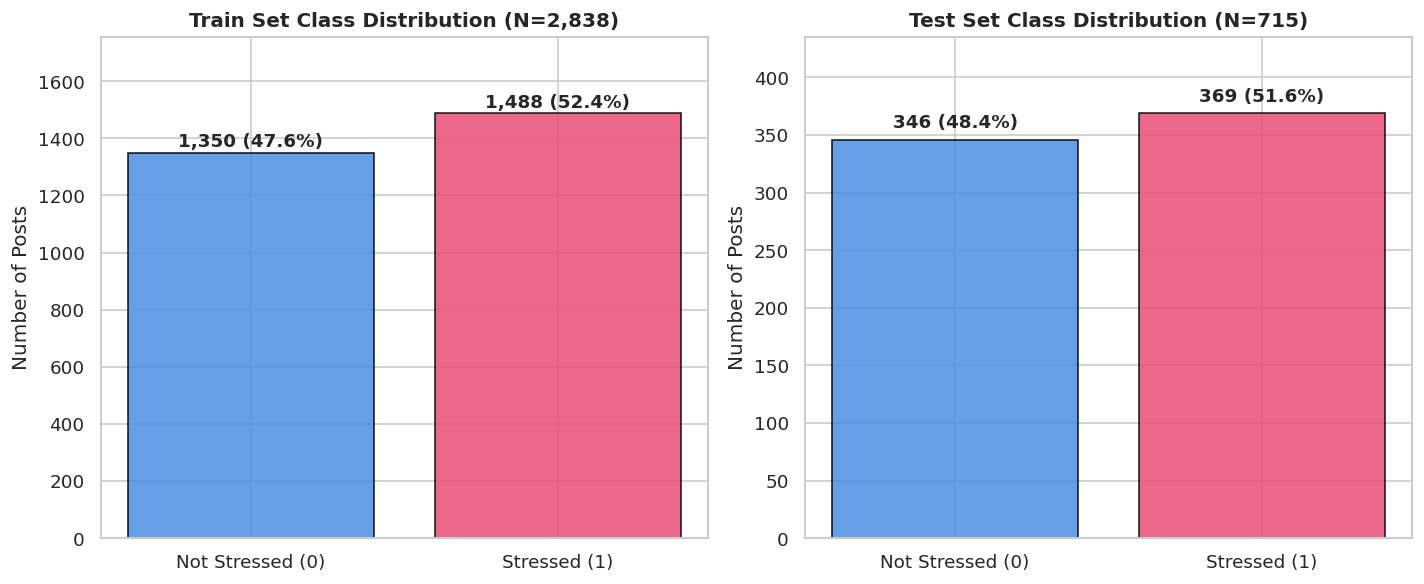

In [5]:
# Plot 1: Class Distribution Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = ["#4A90E2", "#E94E77"]
labels = ["Not Stressed (0)", "Stressed (1)"]

bars1 = axes[0].bar(labels, df_train["label"].value_counts().sort_index(), color=palette, edgecolor="black", alpha=0.85)
axes[0].set_title(f"Train Set Class Distribution (N={len(df_train):,})", fontsize=12, weight="bold")
axes[0].set_ylabel("Number of Posts")
axes[0].set_ylim(0, df_train["label"].value_counts().max() * 1.18)
for b in bars1:
    y = b.get_height()
    axes[0].text(b.get_x() + b.get_width() / 2, y + 20, f"{y:,} ({(y/len(df_train))*100:.1f}%)", ha="center", weight="bold")

bars2 = axes[1].bar(labels, df_test["label"].value_counts().sort_index(), color=palette, edgecolor="black", alpha=0.85)
axes[1].set_title(f"Test Set Class Distribution (N={len(df_test):,})", fontsize=12, weight="bold")
axes[1].set_ylabel("Number of Posts")
axes[1].set_ylim(0, df_test["label"].value_counts().max() * 1.18)
for b in bars2:
    y = b.get_height()
    axes[1].text(b.get_x() + b.get_width() / 2, y + 10, f"{y:,} ({(y/len(df_test))*100:.1f}%)", ha="center", weight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=300)
plt.show()

### 4. Text Length Profiling & Linguistic Density
Compute character counts, word counts, and statistical metrics across classes.

In [6]:
df_comb = pd.concat([df_train, df_test], ignore_index=True)
df_comb["char_length"] = df_comb["text"].astype(str).apply(len)
df_comb["word_count"] = df_comb["text"].astype(str).apply(lambda x: len(x.split()))

stats_summary = df_comb.groupby("label")[["word_count", "char_length"]].describe()
display(stats_summary)

word_count                                                       \
           count       mean        std  min   25%   50%    75%    max   
label                                                                   
0         1696.0  82.166274  29.146331  1.0  63.0  78.0   97.0  255.0   
1         1857.0  88.784599  34.240527  1.0  67.0  83.0  105.0  310.0   

      char_length                                                            
            count        mean         std  min    25%    50%    75%     max  
label                                                                        
0          1696.0  434.918632  154.624422  6.0  335.0  413.0  516.0  1358.0  
1          1857.0  459.315563  178.504095  6.0  342.0  428.0  544.0  1639.0

C:\Users\gargd\AppData\Local\Temp\ipykernel_8596\4286548491.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gargd\AppData\Local\Temp\ipykernel_8596\4286548491.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Not Stressed (0)", "Stressed (1)"])


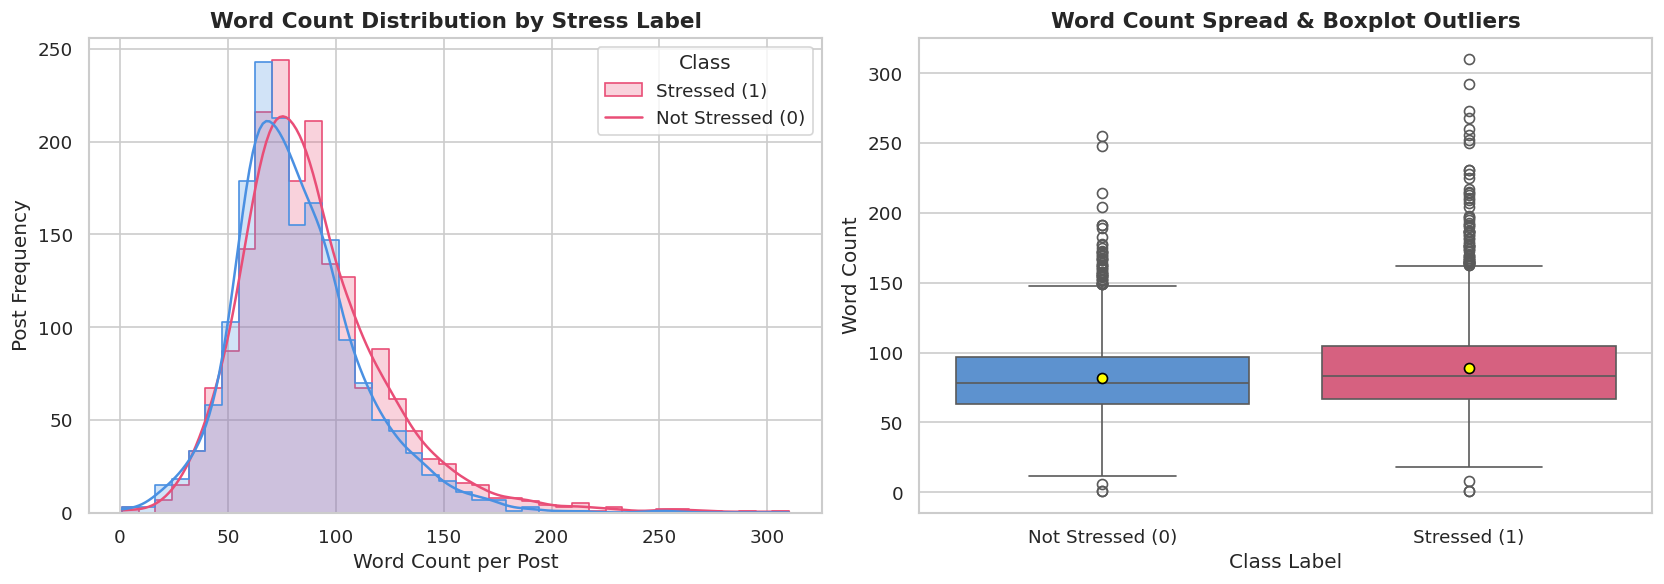

In [7]:
# Plot 2: Text Length Distribution & Spread
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_comb,
    x="word_count",
    hue="label",
    kde=True,
    element="step",
    bins=40,
    palette={0: "#4A90E2", 1: "#E94E77"},
    ax=axes[0]
)
axes[0].set_title("Word Count Distribution by Stress Label", fontsize=13, weight="bold")
axes[0].set_xlabel("Word Count per Post")
axes[0].set_ylabel("Post Frequency")
axes[0].legend(title="Class", labels=["Stressed (1)", "Not Stressed (0)"])

sns.boxplot(
    data=df_comb,
    x="label",
    y="word_count",
    palette=["#4A90E2", "#E94E77"],
    ax=axes[1],
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "yellow", "markeredgecolor": "black"}
)
axes[1].set_title("Word Count Spread & Boxplot Outliers", fontsize=13, weight="bold")
axes[1].set_xticklabels(["Not Stressed (0)", "Stressed (1)"])
axes[1].set_xlabel("Class Label")
axes[1].set_ylabel("Word Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_length_distribution.png", dpi=300)
plt.show()

### 5. Inspect Qualitative Samples (5 Stressed vs 5 Not Stressed)

In [8]:
print("="*80)
print("STRESSED POSTS EXAMPLES (Label = 1)")
print("="*80)
for i, text in enumerate(df_train[df_train["label"] == 1]["text"].head(5), 1):
    print(f"\n[Example {i}]:\n{text}\n")

print("="*80)
print("NOT STRESSED POSTS EXAMPLES (Label = 0)")
print("="*80)
for i, text in enumerate(df_train[df_train["label"] == 0]["text"].head(5), 1):
    print(f"\n[Example {i}]:\n{text}\n")

STRESSED POSTS EXAMPLES (Label = 1)

[Example 1]:
He said he had not felt that way before, suggeted I go rest and so ..TRIGGER AHEAD IF YOUI'RE A HYPOCONDRIAC LIKE ME: i decide to look up "feelings of doom" in hopes of maybe getting sucked into some rabbit hole of ludicrous conspiracy, a stupid "are you psychic" test or new age b.s., something I could even laugh at down the road. No, I ended up reading that this sense of doom can be indicative of various health ailments; one of which I am prone to.. So on top of my "doom" to my gloom..I am now f'n worried about my heart. I do happen to have a physical in 48 hours.


[Example 2]:
My mom then hit me with the newspaper and it shocked me that she would do this, she knows I don't like play hitting, smacking, striking, hitting or violence of any sort on my person. Do I send out this vibe asking for it from the universe? Then yesterday I decided to take my friend to go help another "friend" move to a new place. While we were driving the frien

### 6. Scan for Conversational & Reddit-Specific Artifacts

In [ ]:
url_regex = re.compile(r"https?://\S+|www\.\S+|<url>", re.IGNORECASE)
subreddit_regex = re.compile(r"\br/[A-Za-z0-9_]+", re.IGNORECASE)
user_regex = re.compile(r"\bu/[A-Za-z0-9_-]+", re.IGNORECASE)
deleted_regex = re.compile(r"\[deleted\]|\[removed\]", re.IGNORECASE)

artifacts_summary = pd.DataFrame({
    "Artifact": ["URLs / Links", "Subreddit Mentions (r/)", "User Mentions (u/)", "[deleted] / [removed]"],
    "Train Count": [
        df_train["text"].apply(lambda t: len(url_regex.findall(str(t)))).sum(),
        df_train["text"].apply(lambda t: len(subreddit_regex.findall(str(t)))).sum(),
        df_train["text"].apply(lambda t: len(user_regex.findall(str(t)))).sum(),
        df_train["text"].apply(lambda t: len(deleted_regex.findall(str(t)))).sum(),
    ],
    "Test Count": [
        df_test["text"].apply(lambda t: len(url_regex.findall(str(t)))).sum(),
        df_test["text"].apply(lambda t: len(subreddit_regex.findall(str(t)))).sum(),
        df_test["text"].apply(lambda t: len(user_regex.findall(str(t)))).sum(),
        df_test["text"].apply(lambda t: len(deleted_regex.findall(str(t)))).sum(),
    ]
})
artifacts_summary["Total"] = artifacts_summary["Train Count"] + artifacts_summary["Test Count"]
display(artifacts_summary)

### 7. Word Frequency & Lexical Profiling (Top 20 Words per Class)

In [ ]:
# Plot 3: Top 20 Words Comparison
stop_words = set(stopwords.words("english")).union(
    {"im", "dont", "like", "get", "go", "would", "one", "also", "even", "ive", "really", "cant", "got", "know", "said"}
)

def extract_top_words(texts, n=20):
    words = []
    for text in texts:
        clean = re.findall(r"\b[a-zA-Z]{3,}\b", str(text).lower())
        words.extend([w for w in clean if w not in stop_words])
    return Counter(words).most_common(n)

stressed_top = extract_top_words(df_comb[df_comb["label"] == 1]["text"], n=20)
not_stressed_top = extract_top_words(df_comb[df_comb["label"] == 0]["text"], n=20)

df_s = pd.DataFrame(stressed_top, columns=["word", "count"]).sort_values("count", ascending=True)
df_ns = pd.DataFrame(not_stressed_top, columns=["word", "count"]).sort_values("count", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].barh(df_s["word"], df_s["count"], color="#E94E77", edgecolor="black", alpha=0.85)
axes[0].set_title("Top 20 Frequent Words: Stressed (1)", fontsize=13, weight="bold")
axes[0].set_xlabel("Frequency Count")

axes[1].barh(df_ns["word"], df_ns["count"], color="#4A90E2", edgecolor="black", alpha=0.85)
axes[1].set_title("Top 20 Frequent Words: Not Stressed (0)", fontsize=13, weight="bold")
axes[1].set_xlabel("Frequency Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_words_comparison.png", dpi=300)
plt.show()

### 8. Save Processed Datasets to `data/processed/`

In [ ]:
train_clean_path = PROCESSED_DIR / "dreaddit_train.csv"
test_clean_path = PROCESSED_DIR / "dreaddit_test.csv"

df_train.to_csv(train_clean_path, index=False)
df_test.to_csv(test_clean_path, index=False)

print(f"Saved: {train_clean_path} ({df_train.shape[0]} rows)")
print(f"Saved: {test_clean_path} ({df_test.shape[0]} rows)")
print("EDA and dataset generation pipeline completed successfully!")